 Week 2 Assignment: Tesla Deliveries ML Pipeline
 - Loading and inspecting the dataset
- Checking missing values and duplicates
- Performing Exploratory Data Analysis (EDA)
- Encoding categorical variables
- Creating lag and rolling mean features
- Splitting data chronologically
- Training and evaluating Linear Regression
- Running 5-Fold Cross Validation
- Performing GridSearchCV on RandomForestRegressor
- Running the ADF stationarity test
- Creating a forecast comparison table

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_style("whitegrid")

1. Load Dataset and Inspect Structure

The Tesla deliveries dataset is loaded into a pandas DataFrame.  
We inspect:
- the shape of the dataset
- column names
- data types and non-null counts using `.info()`
- summary statistics using `.describe()`

In [5]:
df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe(include='all'))

Shape of dataset: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-n

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


2. Check Missing Values and Duplicate Rows

Before analysis and modeling, it is important to check for:
- missing values in each column
- duplicate rows in the dataset

In [6]:
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Number of duplicate rows: 0


3. Create a Proper Date Column for Time-Based Analysis

The dataset does not contain a direct `Date` column, but it includes `Year` and `Month`.
To perform chronological sorting, time-trend plotting, lag feature creation, and forecasting, a new `Date` column is created by combining `Year` and `Month`.

In [7]:
df['Date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))
df = df.sort_values('Date').reset_index(drop=True)
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


4. Exploratory Data Analysis (EDA)

EDA is used to understand the distribution and relationships in the Tesla deliveries dataset.
The assignment requires five charts:

1. Deliveries by Model
2. Deliveries by Region
3. Correlation Heatmap
4. Production vs Deliveries Scatter Plot
5. Time-Trend Line Plot

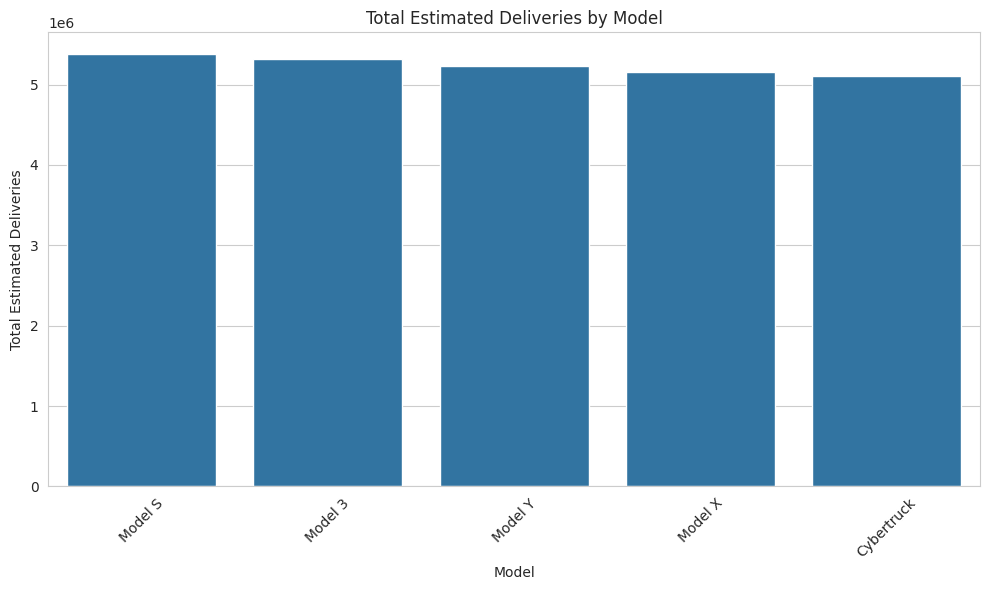

In [8]:
plt.figure(figsize=(10, 6))
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
sns.barplot(x=model_deliveries.index, y=model_deliveries.values)
plt.title("Total Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Total Estimated Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

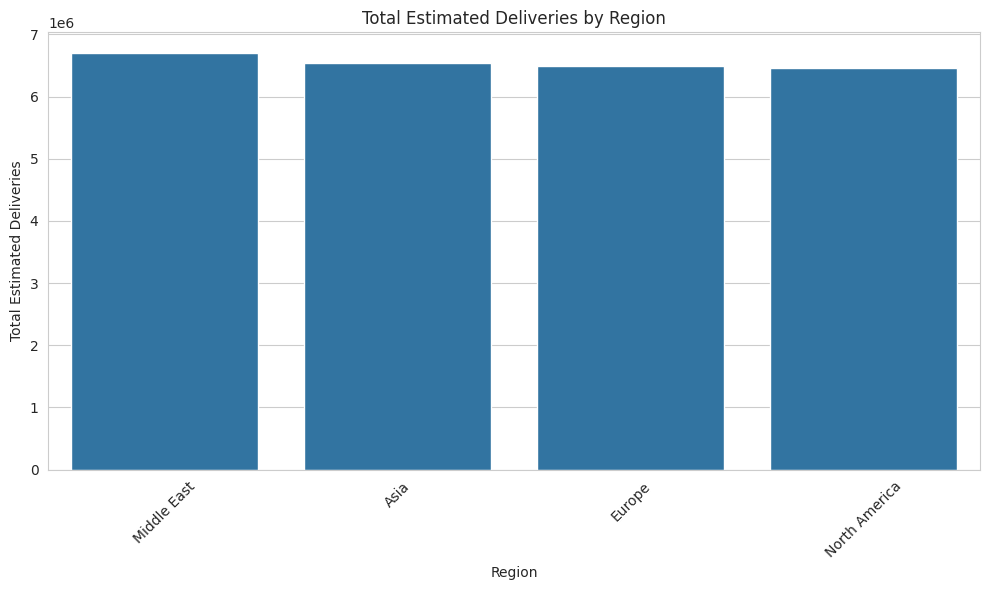

In [9]:
plt.figure(figsize=(10, 6))
region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
sns.barplot(x=region_deliveries.index, y=region_deliveries.values)
plt.title("Total Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Total Estimated Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

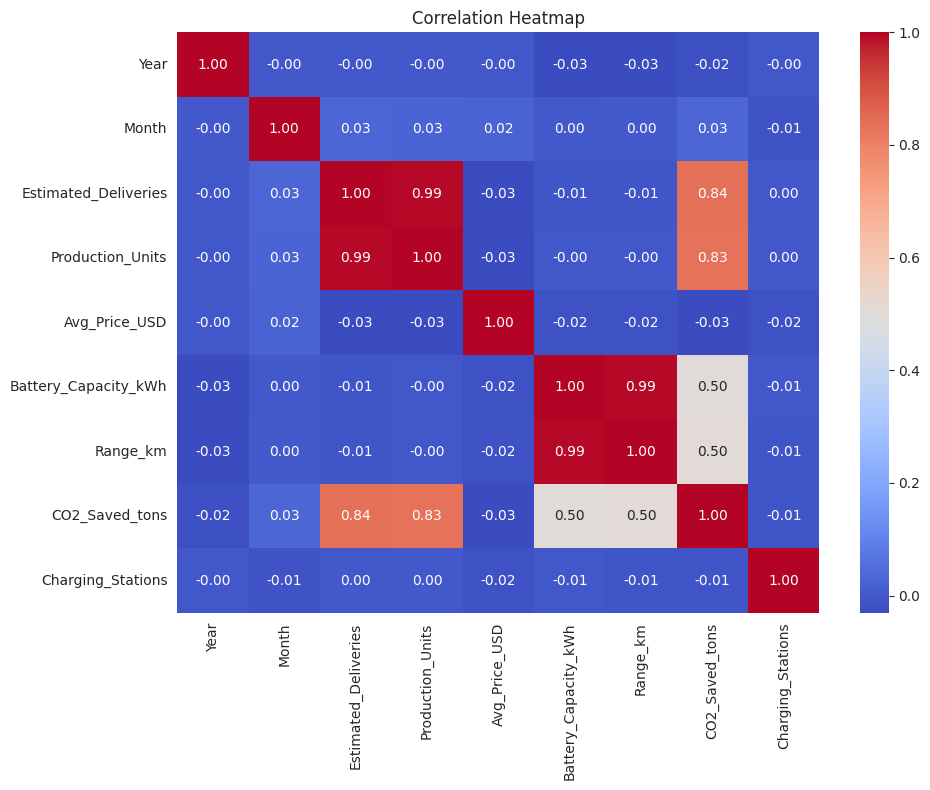

In [10]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

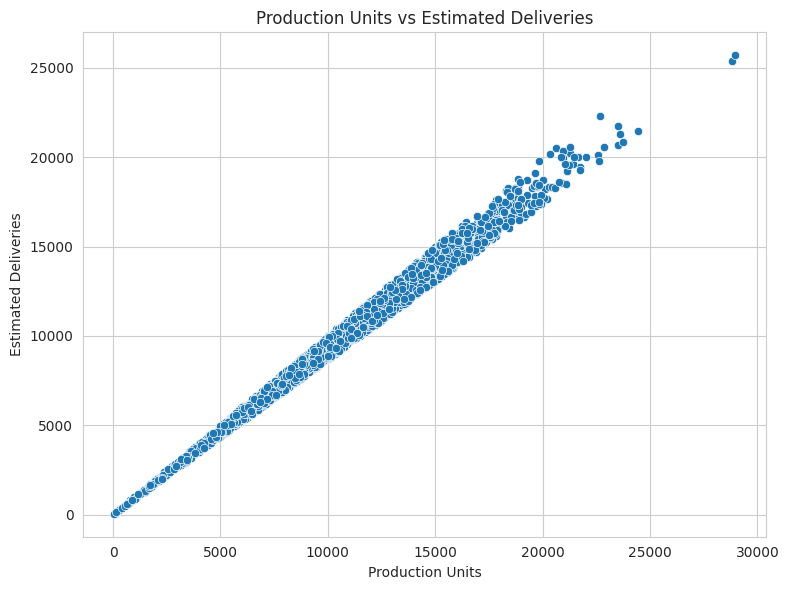

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Production_Units', y='Estimated_Deliveries')
plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()

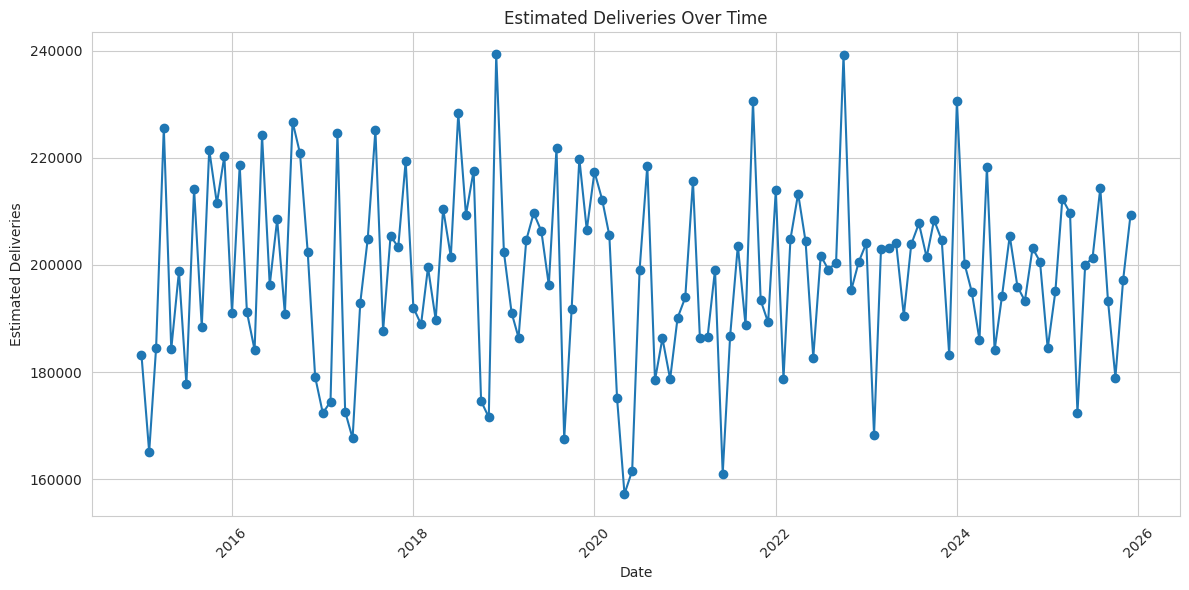

In [12]:
time_trend = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(time_trend['Date'], time_trend['Estimated_Deliveries'], marker='o')
plt.title("Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. Encode Categorical Variables and Create Engineered Features

Machine learning models require numerical inputs, so the following categorical columns are encoded using `LabelEncoder`:
- `Region`
- `Model`
- `Source_Type`

Two additional time-based engineered features are created:
- `Deliveries_Lag1`: previous row's delivery value using a lag of 1
- `Rolling_Mean_3`: rolling average of deliveries over a 3-row window

In [13]:
label_encoders = {}

for col in ['Region', 'Model', 'Source_Type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


In [14]:
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,2015-01-01
1,2015,1,2,1,11446,12752,89289.40,100,588,1009.54,0,8925,2015-01-01
2,2015,1,2,0,8803,9344,102888.58,60,336,443.67,1,3923,2015-01-01
3,2015,1,3,0,6367,6802,104962.32,82,459,438.37,0,9170,2015-01-01
4,2015,1,0,1,8795,9165,87988.73,82,456,601.58,2,12626,2015-01-01


6. Feature Engineering: Lag and Rolling Mean Features

To capture short-term temporal patterns in deliveries, two new features are created:
- **Deliveries_Lag1**: previous record’s `Estimated_Deliveries`
- **Rolling_Mean_3**: rolling average of `Estimated_Deliveries` over a 3-record window

In [15]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()


df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(df['Deliveries_Lag1'].mean())
df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(df['Rolling_Mean_3'].mean())

display(df[['Estimated_Deliveries', 'Deliveries_Lag1', 'Rolling_Mean_3']].head(10))

,Estimated_Deliveries,Deliveries_Lag1,Rolling_Mean_3
0,12446,9922.428192,9921.338261
1,11446,12446.000000,9921.338261
2,8803,11446.000000,10898.333333
3,6367,8803.000000,8872.000000
4,8795,6367.000000,7988.333333
5,2161,8795.000000,5774.333333
6,11986,2161.000000,7647.333333
7,8833,11986.000000,7660.000000
8,9446,8833.000000,10088.333333
9,4350,9446.000000,7543.000000


7. Feature Selection and Chronological Train-Test Split

The target variable for prediction is:
- `Estimated_Deliveries`

To preserve the time sequence of the data, the dataset is split chronologically using index slicing instead of `train_test_split`.

- First 80% of rows → training set
- Last 20% of rows → testing set


In [16]:
target_col = 'Estimated_Deliveries'

feature_cols = [col for col in df.columns if col not in [target_col, 'Date']]

X = df[feature_cols]
y = df[target_col]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

print("\nFeature columns used:")
print(feature_cols)

Training set shape: (2112, 13) (2112,)
Testing set shape: (528, 13) (528,)

Feature columns used:
['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Deliveries_Lag1', 'Rolling_Mean_3']


8. Train Linear Regression and Evaluate Performance

A Linear Regression model is trained as a baseline regression model to predict `Estimated_Deliveries`.

The model is evaluated using:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **R² Score**

In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"MAE  : {mae_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression Performance:
MAE  : 323.1618
RMSE : 392.2208
R²   : 0.9884


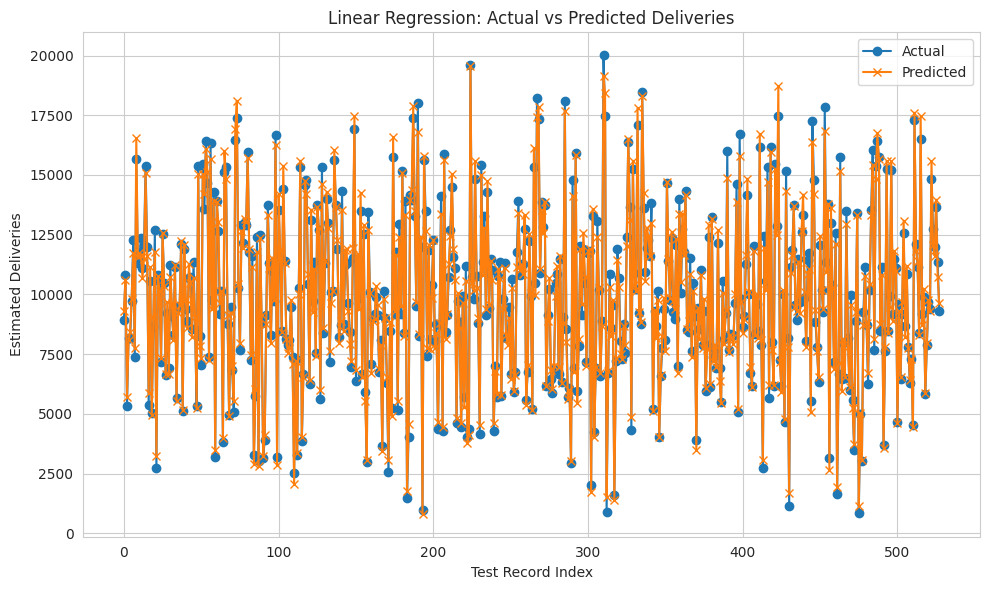

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred_lr, label='Predicted', marker='x')
plt.title("Linear Regression: Actual vs Predicted Deliveries")
plt.xlabel("Test Record Index")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

9. Perform 5-Fold Cross Validation on Linear Regression

To estimate how well Linear Regression generalizes across different subsets of the data, 5-Fold Cross Validation is performed.


In [19]:
kf = KFold(n_splits=5, shuffle=False)

cv_scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')

print("5-Fold Cross Validation R² Scores:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean R²: {cv_scores.mean():.4f}")

5-Fold Cross Validation R² Scores:
Fold 1: 0.9902
Fold 2: 0.9911
Fold 3: 0.9909
Fold 4: 0.9907
Fold 5: 0.9884

Mean R²: 0.9903


10. Hyperparameter Tuning with GridSearchCV on RandomForestRegressor

A RandomForestRegressor is tuned using GridSearchCV to improve predictive performance.

The parameter grid is:
- `n_estimators = [50, 100]`
- `max_depth = [5, 10, None]`

In [20]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best CV Score: 0.9888872764288837


In [21]:
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance:
MAE  : 329.8015
RMSE : 411.4679
R²   : 0.9873


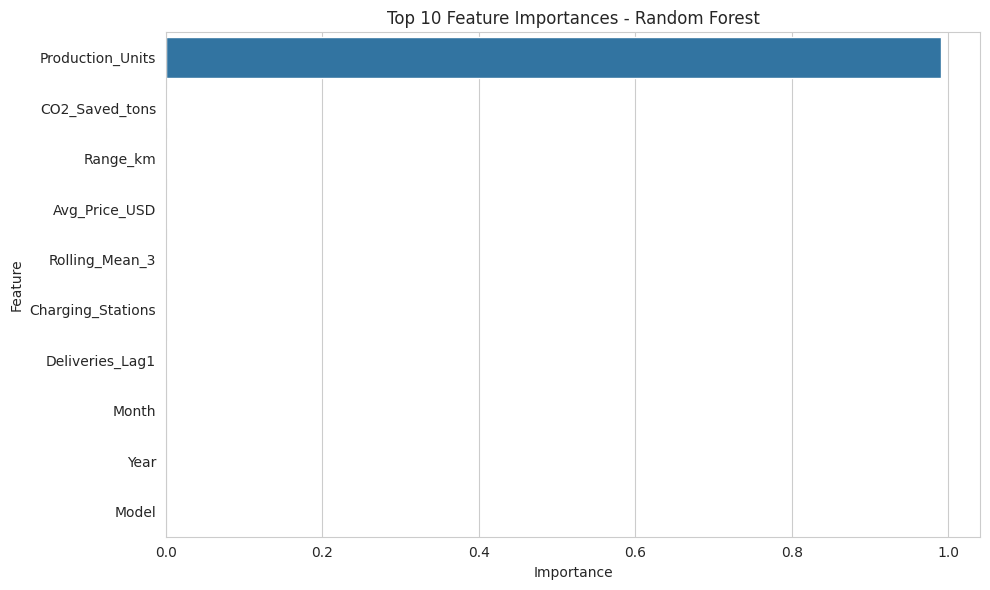

In [22]:
feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_10_features = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values, y=top_10_features.index)
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

11. Augmented Dickey-Fuller (ADF) Stationarity Test

The ADF test is applied to the `Estimated_Deliveries` series to check whether it is stationary.

### Interpretation rule:
- **p-value < 0.05** → the series is likely stationary
- **p-value >= 0.05** → the series is likely non-stationary

In [23]:
adf_result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of lags used:", adf_result[2])
print("Number of observations used:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

if adf_result[1] < 0.05:
    print("\nInterpretation: p-value < 0.05, so the Estimated_Deliveries series is likely stationary.")
else:
    print("\nInterpretation: p-value >= 0.05, so the Estimated_Deliveries series is likely non-stationary.")

ADF Statistic: -28.17620446835788
p-value: 0.0
Number of lags used: 2
Number of observations used: 2637

Critical Values:
1%: -3.4328322438338814
5%: -2.862636667186374
10%: -2.5673537941697515

Interpretation: p-value < 0.05, so the Estimated_Deliveries series is likely stationary.


12. Forecast Table and Final Conclusion

To evaluate the practical forecasting performance of the tuned model, a forecast comparison table is created for the first 20 records in the test set.

The table includes:
- Actual delivery values
- Predicted delivery values
- Error percentage


In [24]:
forecast_df = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': y_pred_rf[:20]
})

forecast_df['Error_%'] = np.where(
    forecast_df['Actual'] != 0,
    np.abs((forecast_df['Actual'] - forecast_df['Predicted']) / forecast_df['Actual']) * 100,
    np.nan
)

print("Forecast Comparison Table (First 20 Test Records):")
display(forecast_df)

Forecast Comparison Table (First 20 Test Records):


,Actual,Predicted,Error_%
0,8910,9117.02,2.323457
1,10819,10618.91,1.849432
2,5341,5522.60,3.400112
3,8195,8071.23,1.510311
4,8179,8468.01,3.533562
5,9742,9685.32,0.581811
6,12266,11885.07,3.105576
7,7375,7629.96,3.457085
8,15680,16253.90,3.660077
9,11323,11691.79,3.256999
